## False Positive Analysis

In [4]:

import os
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import go3

# ── Globals ───────────────────────────────────────────────────────────────────
RESULTS_ROOT = "/home/atoffano/PFP_layer/results"
DATASETS     = ["ATGO", "D1"]
SUBONTOLOGIES = ["BPO", "MFO", "CCO"]
SPLIT        = "test"

PLOTS_DIR = os.path.join(os.getcwd(), "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.rcParams.update({"font.size": 22, "legend.fontsize": 18})

def save_and_show(fig, filename):
    name_root, _ = os.path.splitext(filename)
    out_path = os.path.join(PLOTS_DIR, f"{name_root}.svg")
    fig.savefig(out_path, format="svg", bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

# ── GO helpers ─────────────────────────────────────────────────────────────────
go3.load_go_terms('/home/atoffano/PFP_layer/data/go.obo')

def go_name(go_id: str) -> str:
    try:
        term = go3.get_term_by_id(go_id)
        return term.name if term is not None else go_id
    except Exception:
        return go_id

def _safe_go_name(go_id):
    try:
        return go_name(go_id)
    except Exception:
        return go_id

# ── I/O helpers ────────────────────────────────────────────────────────────────
def _load_predictions(pred_path):
    if not os.path.exists(pred_path):
        return pd.DataFrame()
    df = pd.read_csv(pred_path, sep='\t')
    if 'term_ID' not in df.columns and 'term' in df.columns:
        df = df.rename(columns={'term': 'term_ID'})
    if 'target_ID' not in df.columns and 'EntryID' in df.columns:
        df = df.rename(columns={'EntryID': 'target_ID'})
    needed = {'target_ID', 'term_ID', 'score'}
    return df if needed.issubset(df.columns) else pd.DataFrame()

def _load_ground_truth(gt_path):
    if not os.path.exists(gt_path):
        return pd.DataFrame()
    rows = []
    with open(gt_path, 'r') as f:
        next(f, None)
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue
            pid = parts[0]
            for t in [x.strip() for x in parts[1].split(';') if x.strip()]:
                rows.append({'target_ID': pid, 'term_ID': t})
    return pd.DataFrame(rows)

def _load_ic_map(ic_path):
    if not os.path.exists(ic_path):
        return pd.Series(dtype=float)
    ic_df = pd.read_csv(ic_path, sep='\t', header=None, names=['term_ID', 'ic'])
    return ic_df.set_index('term_ID')['ic'] if not ic_df.empty else pd.Series(dtype=float)

def _split_tp_fp(df_pred, df_gt):
    if df_pred.empty or df_gt.empty:
        return pd.DataFrame(), pd.DataFrame()
    merged = df_pred.merge(
        df_gt[['target_ID', 'term_ID']].drop_duplicates(),
        on=['target_ID', 'term_ID'], how='left', indicator=True,
    )
    tp = merged[merged['_merge'] == 'both'].copy()
    fp = merged[merged['_merge'] == 'left_only'].copy()
    return tp, fp

def _prep_plot_df(df, ic_map, metric='score', min_count=20, top_k=20, ascending=True):
    if df.empty:
        return pd.DataFrame(), []
    out = df.copy()
    out['term_name'] = out['term_ID'].map(_safe_go_name)
    out['ic']       = out['term_ID'].map(ic_map).fillna(0.0)
    out['score_ic'] = out['score'] * out['ic']
    val_col = 'score' if metric == 'score' else 'score_ic'
    out = out[out['ic'] > 0].copy()
    counts = out['term_name'].value_counts()
    out = out[out['term_name'].isin(counts[counts >= min_count].index)].copy()
    if out.empty:
        return out, []
    counts = out['term_name'].value_counts()
    out['term_label'] = out['term_name'].map(lambda t: f"{t} (n={counts.get(t, 0)})")
    order = (
        out.groupby('term_label')[val_col]
        .median()
        .sort_values(ascending=ascending)
        .head(top_k)
        .index
        .tolist()
    )
    return out, order


In [5]:

def run_tp_analysis_subplots_for_model(
    model_sub_pairs,
    dataset='D1',
    split='test',
    subontologies=('BPO', 'MFO', 'CCO'),
    results_root=RESULTS_ROOT,
    data_root='/home/atoffano/PFP_layer/data',
    min_count=20,
    top_k=25,
    ic_weighted=False,
    ascending=False,
):
    """
    One-row, one-column-per-subontology plot showing the distribution of
    true-positive (TP) prediction scores per GO term.

    For each subontology the model in *model_sub_pairs* is used.
    Predictions that match a ground-truth annotation are considered TP.
    Box-and-strip plots show the score distribution; median marker (◇) is added.

    Parameters
    ----------
    model_sub_pairs : list of (model_dir, subontology) tuples
        First match for each subontology is used.
    ic_weighted : bool
        If True, plot score × IC instead of raw score.
    ascending : bool
        Sort order for terms along the x-axis.
    """
    ordered_subontologies = ['BPO', 'MFO', 'CCO']
    metric  = 'score_ic' if ic_weighted else 'score'
    y_col   = 'score_ic' if ic_weighted else 'score'
    ylabel  = 'TP IC-weighted Score' if ic_weighted else 'TP Prediction Score'

    palette    = sns.color_palette()
    sub_colors = {'BPO': palette[0], 'MFO': palette[1], 'CCO': palette[2]}

    # Build sub → model_dir mapping (first match wins)
    sub_to_model = {}
    for model_dir, sub in model_sub_pairs:
        if sub in ordered_subontologies and sub not in sub_to_model:
            sub_to_model[sub] = model_dir

    active_subs = [s for s in ordered_subontologies if s in subontologies]
    n_cols = len(active_subs)
    if n_cols == 0:
        print("No subontologies to plot.")
        return

    fig, axes = plt.subplots(1, n_cols, figsize=(9 * n_cols, 9), sharey=False)
    if n_cols == 1:
        axes = [axes]

    for ax, sub in zip(axes, active_subs):
        if sub not in sub_to_model:
            ax.text(0.5, 0.5, f'No model for {sub}', ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_axis_off()
            ax.set_title(sub)
            continue

        model_dir = sub_to_model[sub]
        pred_path = os.path.join(results_root, dataset, model_dir, 'predictions',
                                 f'predictions_{split}_{sub}.tsv')
        gt_path   = os.path.join(data_root, dataset,
                                 f'{dataset}_{sub}_{split}_annotations.tsv')
        ic_path   = os.path.join(data_root, dataset, f'IA_{dataset}_{sub}.tsv')

        df_pred = _load_predictions(pred_path)
        df_gt   = _load_ground_truth(gt_path)
        ic_map  = _load_ic_map(ic_path)
        tp, _   = _split_tp_fp(df_pred, df_gt)

        tp_df, tp_order = _prep_plot_df(
            tp, ic_map, metric=metric,
            min_count=min_count, top_k=top_k, ascending=ascending,
        )

        if tp_df.empty or not tp_order:
            ax.text(0.5, 0.5, f'No TP data for {sub}', ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_axis_off()
            ax.set_title(sub)
            continue

        sns.boxplot(
            data=tp_df, x='term_label', y=y_col,
            order=tp_order, color=sub_colors.get(sub, 'steelblue'),
            showfliers=False, ax=ax,
        )
        sns.stripplot(
            data=tp_df, x='term_label', y=y_col,
            order=tp_order, color='black',
            size=1.8, alpha=0.35, jitter=0.25, ax=ax,
        )
        medians = tp_df.groupby('term_label')[y_col].median().reindex(tp_order)
        ax.scatter(
            range(len(tp_order)), medians.values,
            facecolor='white', edgecolor='black', marker='D', s=30, zorder=5,
            label='Median',
        )

        model_short = model_dir.split('GNN_')[-1]
        ax.set_title(f'{sub}\n{model_short}', fontsize=11)
        ax.set_ylabel(ylabel if ax is axes[0] else '', fontsize=11)
        ax.set_xlabel('', fontsize=10)
        ax.tick_params(axis='x', rotation=40, labelsize=8)
        for lbl in ax.get_xticklabels():
            lbl.set_horizontalalignment('right')

    mode_tag = 'ic_weighted' if ic_weighted else 'raw_score'
    fig.suptitle(f'True Positive score distribution – {dataset} {split}  [{mode_tag}]',
                 fontsize=13, y=1.01)
    fig.subplots_adjust(bottom=0.35, wspace=0.15)
    save_and_show(fig, f'tp_analysis_subplots_{dataset.lower()}_{mode_tag}.svg')


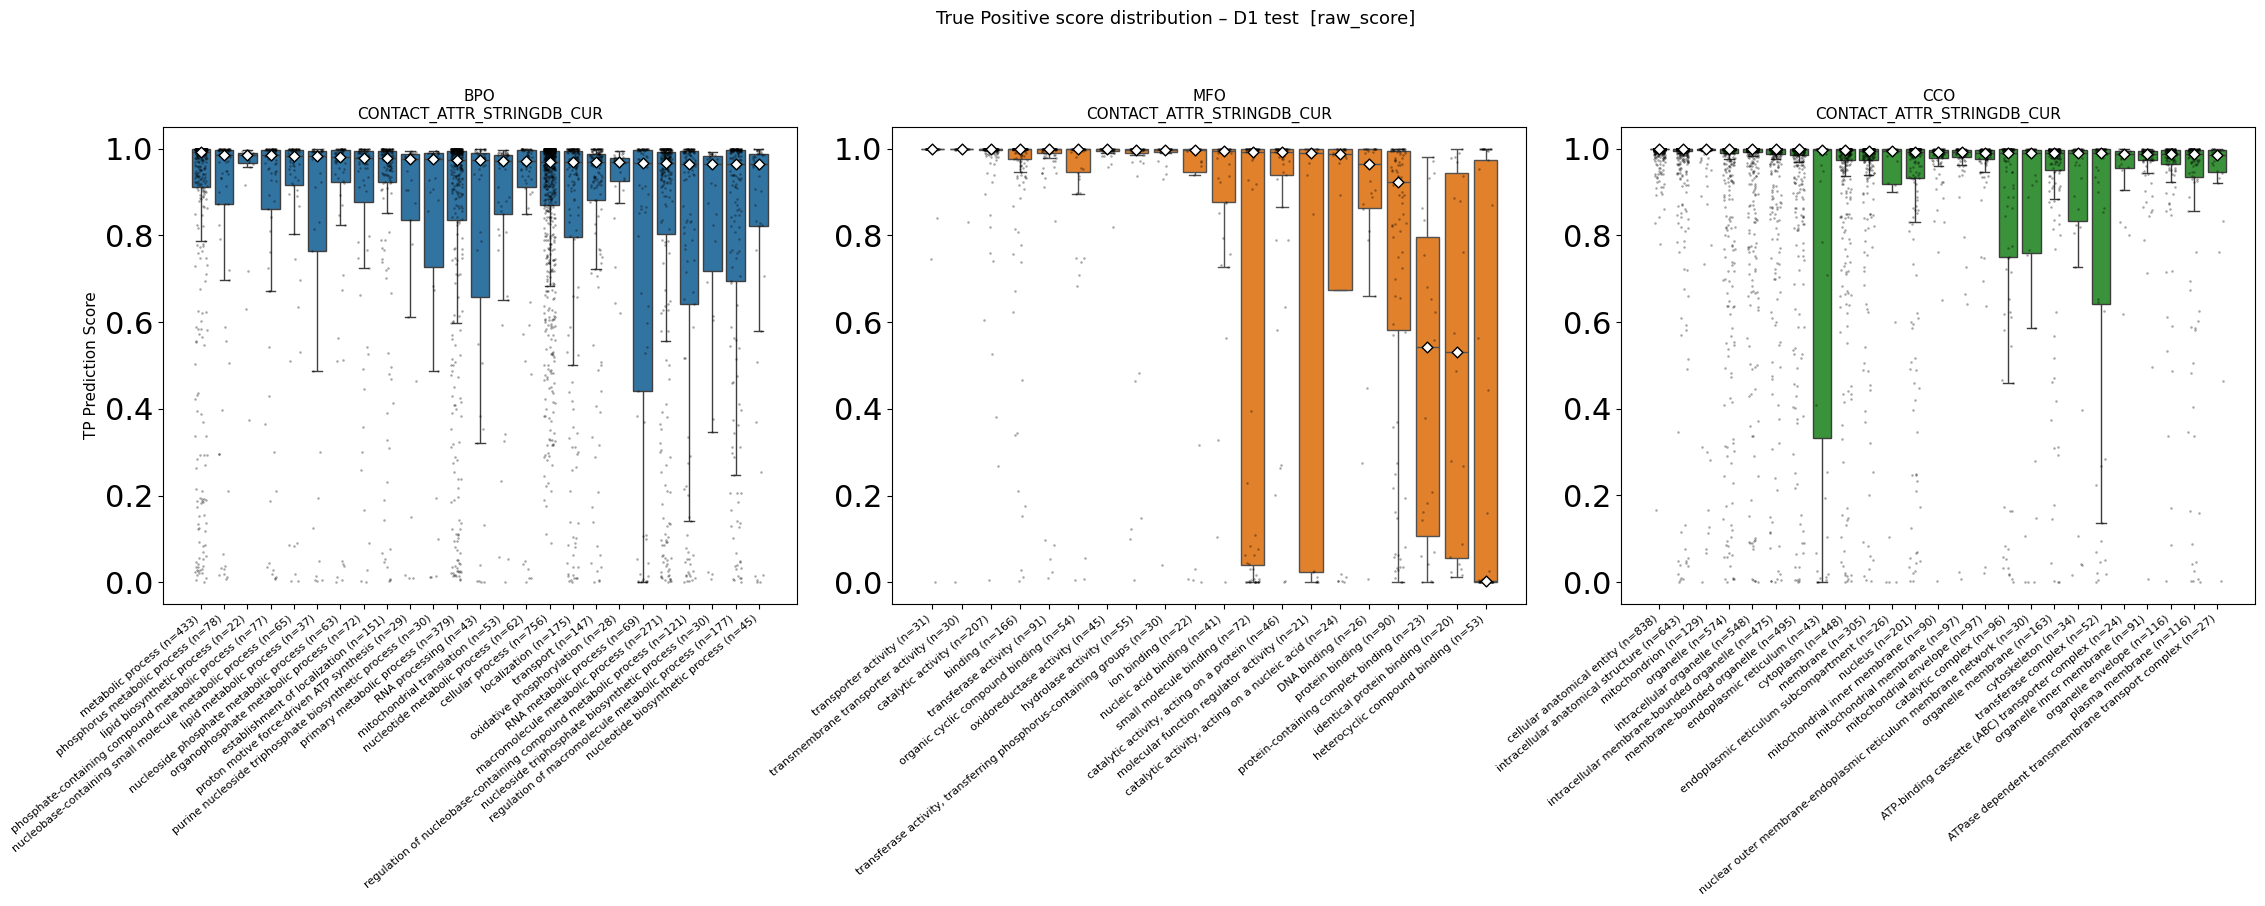

Saved: /home/atoffano/PFP_layer/notebooks/plots/tp_analysis_subplots_d1_raw_score.svg


In [6]:
TP_MODEL_SUBS = [
    ('20260214_100017_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR', 'MFO'),
    ('20260214_105025_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR', 'CCO'),
    ('20260214_110347_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR', 'BPO'),
]

run_tp_analysis_subplots_for_model(
    model_sub_pairs=TP_MODEL_SUBS,
    dataset='D1',
    split='test',
    subontologies=('BPO', 'MFO', 'CCO'),
    results_root=RESULTS_ROOT,
    data_root='/home/atoffano/PFP_layer/data',
    min_count=20,
    top_k=25,
    ic_weighted=False,
    ascending=False,
)


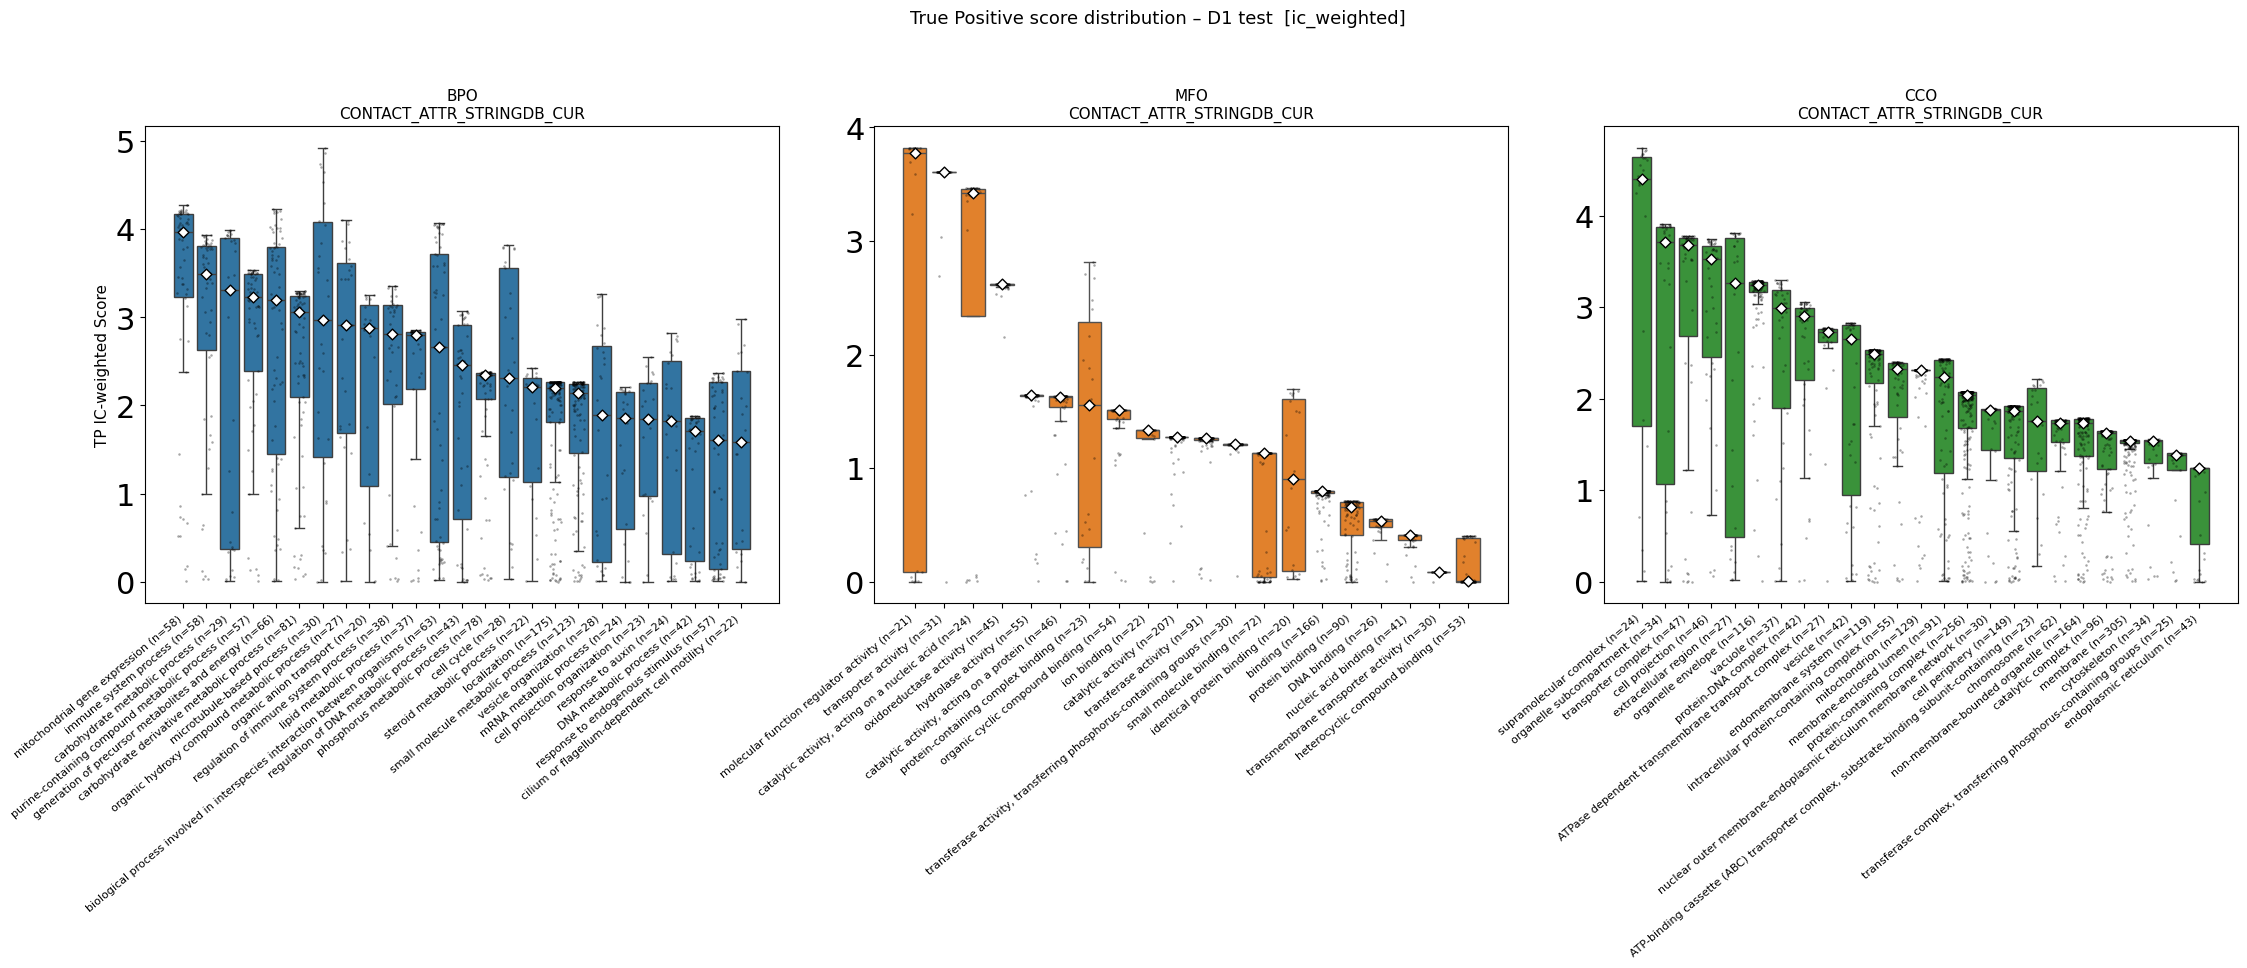

Saved: /home/atoffano/PFP_layer/notebooks/plots/tp_analysis_subplots_d1_ic_weighted.svg


In [7]:
run_tp_analysis_subplots_for_model(
    model_sub_pairs=TP_MODEL_SUBS,
    dataset='D1',
    split='test',
    subontologies=('BPO', 'MFO', 'CCO'),
    results_root=RESULTS_ROOT,
    data_root='/home/atoffano/PFP_layer/data',
    min_count=20,
    top_k=25,
    ic_weighted=True,
    ascending=False,
)

In [8]:

import collections
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.gridspec as gridspec


def _get_all_ancestors(term_id: str) -> set:
    """
    Return the set of all ancestor GO IDs for term_id (inclusive),
    walking up through is_a parent edges via go3.
    """
    visited = set()
    queue = collections.deque([term_id])
    while queue:
        tid = queue.popleft()
        if tid in visited:
            continue
        visited.add(tid)
        term = go3.get_term_by_id(tid)
        if term is None:
            continue
        for parent in term.parents:
            if parent not in visited:
                queue.append(parent)
    return visited


def _lin_distance_matrix(term_ids: list, ic_map) -> np.ndarray:
    """
    Build a symmetric (n × n) distance matrix based on Lin semantic similarity:

        Lin(t1, t2) = 2 * IC(MICA) / (IC(t1) + IC(t2))
        distance    = 1 - Lin(t1, t2)

    where MICA is the Most Informative Common Ancestor (highest IC among shared
    ancestors). IC values come from the dataset-specific ic_map already loaded
    from the local IA TSV file.

    Terms with IC = 0, missing IC, or no common ancestor default to distance 1.
    """
    n = len(term_ids)
    # Cache ancestor sets to avoid redundant traversals
    ancestor_cache = {tid: _get_all_ancestors(tid) for tid in term_ids}

    mat = np.zeros((n, n))
    for i in range(n):
        ic_i = float(ic_map.get(term_ids[i], 0.0))
        for j in range(i + 1, n):
            ic_j = float(ic_map.get(term_ids[j], 0.0))
            denom = ic_i + ic_j
            if denom == 0.0:
                dist = 1.0
            else:
                common = ancestor_cache[term_ids[i]] & ancestor_cache[term_ids[j]]
                if not common:
                    dist = 1.0
                else:
                    ic_mica = max(
                        (float(ic_map.get(a, 0.0)) for a in common),
                        default=0.0,
                    )
                    lin_sim = (2.0 * ic_mica) / denom
                    # Clamp to [0, 1] to guard against any floating-point overshoot
                    lin_sim = min(1.0, max(0.0, lin_sim))
                    dist = 1.0 - lin_sim
            mat[i, j] = dist
            mat[j, i] = dist
    return mat


def run_tp_cluster_subplots_for_model(
    model_sub_pairs,
    dataset='D1',
    split='test',
    subontologies=('BPO', 'MFO', 'CCO'),
    results_root=RESULTS_ROOT,
    data_root='/home/atoffano/PFP_layer/data',
    min_count=20,
    top_k=20,
    ic_weighted=False,
    ascending=False,
    linkage_method='average',
):
    """
    Same as run_tp_analysis_subplots_for_model(), but each subplot is split
    vertically into a dendrogram (top) and a boxplot (bottom). The x-axis
    order of the boxplot follows the dendrogram leaf order.

    Clustering uses Lin semantic similarity (1 − Lin) as the distance between
    GO terms: terms that share a high-IC most-informative common ancestor are
    placed adjacent in the dendrogram. IC values come from the per-dataset
    IA TSV files.
    """
    ordered_subontologies = ['BPO', 'MFO', 'CCO']
    metric = 'score_ic' if ic_weighted else 'score'
    y_col  = 'score_ic' if ic_weighted else 'score'
    ylabel = 'TP IC-weighted Score' if ic_weighted else 'TP Prediction Score'

    palette    = sns.color_palette()
    sub_colors = {'BPO': palette[0], 'MFO': palette[1], 'CCO': palette[2]}

    def _clip_term_label(txt, max_len=35):
        txt = str(txt)
        if txt.endswith(')') and ' (n=' in txt:
            base, cnt = txt.rsplit(' (n=', 1)
            cnt = cnt.rstrip(')')
            suffix = f' (n={cnt})'
            available = max_len - len(suffix)
            base = base[:available - 1] + '—' if len(base) > available else base
            return f'{base}{suffix}'
        return txt if len(txt) <= max_len else (txt[:max_len - 1] + '—')

    # sub -> model_dir (first match wins)
    sub_to_model = {}
    for model_dir, sub in model_sub_pairs:
        if sub in ordered_subontologies and sub not in sub_to_model:
            sub_to_model[sub] = model_dir

    # Figure: 3 columns, each column has 2 rows (dendrogram on top, boxplot below)
    fig = plt.figure(figsize=(18, 9))
    outer_gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.12)

    for col_idx, sub in enumerate(ordered_subontologies):
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            2, 1,
            subplot_spec=outer_gs[col_idx],
            height_ratios=[1, 3],
            hspace=0.04,
        )
        ax_dendro = fig.add_subplot(inner_gs[0])
        ax_box    = fig.add_subplot(inner_gs[1])

        if sub not in subontologies or sub not in sub_to_model:
            ax_dendro.axis('off')
            ax_box.axis('off')
            ax_box.set_title(sub)
            continue

        model_dir = sub_to_model[sub]
        pred_path = os.path.join(results_root, dataset, model_dir, 'predictions', f'predictions_{split}_{sub}.tsv')
        gt_path   = os.path.join(data_root, dataset, f'{dataset}_{sub}_{split}_annotations.tsv')
        ic_path   = os.path.join(data_root, dataset, f'IA_{dataset}_{sub}.tsv')
        print(f"  {sub}: {pred_path}")

        df_pred = _load_predictions(pred_path)
        df_gt   = _load_ground_truth(gt_path)
        ic_map  = _load_ic_map(ic_path)
        tp, _   = _split_tp_fp(df_pred, df_gt)

        tp_df, tp_order = _prep_plot_df(
            tp, ic_map,
            metric=metric, min_count=min_count, top_k=top_k, ascending=ascending,
        )

        if tp_df.empty or not tp_order:
            ax_dendro.axis('off')
            ax_box.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax_box.transAxes)
            ax_box.set_axis_off()
            ax_box.set_title(sub)
            continue

        # ------------------------------------------------------------------
        # Build term_label -> term_ID mapping for the selected terms
        # ------------------------------------------------------------------
        selected_labels = set(tp_order)
        sub_tp = tp_df[tp_df['term_label'].isin(selected_labels)].copy()

        label_to_id = (
            sub_tp[['term_label', 'term_ID']]
            .drop_duplicates('term_label')
            .set_index('term_label')['term_ID']
            .to_dict()
        )

        # Preserve only terms we have a GO ID for
        valid_order = [t for t in tp_order if t in label_to_id]
        term_ids    = [label_to_id[t] for t in valid_order]

        if len(valid_order) < 2:
            dend_order = valid_order or tp_order
            ax_dendro.axis('off')
        else:
            print(f"    Computing Lin distances for {len(term_ids)} terms …")
            dist_mat = _lin_distance_matrix(term_ids, ic_map)   # n × n symmetric
            dist_condensed = squareform(dist_mat, checks=False)
            Z = linkage(dist_condensed, method=linkage_method)
            dend = dendrogram(
                Z,
                labels=valid_order,          # term_label strings
                ax=ax_dendro,
                orientation='top',
                color_threshold=0,
                above_threshold_color='#555555',
                leaf_rotation=0,
                no_labels=True,
            )
            dend_order = dend['ivl']         # leaf labels in left-to-right order

            # ------------------------------------------------------------------
            # Align dendrogram x-axis with boxplot x-axis.
            # scipy places n leaves at positions 5, 15, 25, … (step=10).
            # The boxplot places n boxes at integer positions 0, 1, 2, …
            # with default xlim of (-0.5, n-0.5).
            # Mapping: dendro_x = 10 * box_x + 5
            # → dendro xlim for box xlim (-0.5, n-0.5) is (0, 10*n)
            # ------------------------------------------------------------------
            n_leaves = len(dend_order)
            ax_dendro.set_xlim(0, 10 * n_leaves)
            ax_dendro.set_axis_off()

        ax_dendro.set_title(sub, fontsize=12, pad=4)

        # ------------------------------------------------------------------
        # Boxplot ordered by dendrogram leaves
        # ------------------------------------------------------------------
        box_order = [t for t in dend_order if t in selected_labels]
        n_boxes   = len(box_order)

        sns.boxplot(
            data=sub_tp, x='term_label', y=y_col,
            order=box_order, showfliers=False,
            color=sub_colors.get(sub), ax=ax_box,
        )
        sns.stripplot(
            data=sub_tp, x='term_label', y=y_col,
            order=box_order, color='black',
            size=1.8, alpha=0.35, jitter=0.25, ax=ax_box,
        )
        stats = sub_tp.groupby('term_label')[y_col].mean().reindex(box_order)
        ax_box.scatter(
            range(n_boxes), stats.values,
            facecolor='white', edgecolor='black', marker='D', s=24, zorder=5,
        )
        # Pin the boxplot xlim so it matches the dendrogram alignment above
        ax_box.set_xlim(-0.5, n_boxes - 0.5)

        if col_idx == 0:
            ax_box.set_ylabel(ylabel, fontsize=10)
            ax_box.tick_params(axis='y', labelsize=9, left=True, labelleft=True)
        else:
            ax_box.set_ylabel('')
            ax_box.tick_params(axis='y', left=False, labelleft=False)
            ax_box.set_yticks([])

        ax_box.set_xlabel('', fontsize=10)
        ax_box.tick_params(axis='x', rotation=35, labelsize=8)
        ax_box.set_xticklabels(
            [_clip_term_label(t.get_text(), max_len=35) for t in ax_box.get_xticklabels()],
            ha='right',
        )

    mode = 'IC-weighted' if ic_weighted else 'Raw score'
    fig.supxlabel('GO Terms', fontsize=10, y=-0.02)
    fig.subplots_adjust(bottom=0.35, top=0.93)
    save_name = f"tp_cluster_subplots_{dataset.lower()}_{mode.replace(' ', '_').lower()}.svg"
    save_and_show(fig, save_name)
    plt.show()


  BPO: /home/atoffano/PFP_layer/results/D1/20260214_110347_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR/predictions/predictions_test_BPO.tsv
    Computing Lin distances for 25 terms …
  MFO: /home/atoffano/PFP_layer/results/D1/20260214_100017_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR/predictions/predictions_test_MFO.tsv


/tmp/ipykernel_2953375/1356997086.py:247: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_xticklabels(


    Computing Lin distances for 20 terms …


/tmp/ipykernel_2953375/1356997086.py:247: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_xticklabels(


  CCO: /home/atoffano/PFP_layer/results/D1/20260214_105025_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR/predictions/predictions_test_CCO.tsv
    Computing Lin distances for 25 terms …


/tmp/ipykernel_2953375/1356997086.py:247: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_xticklabels(


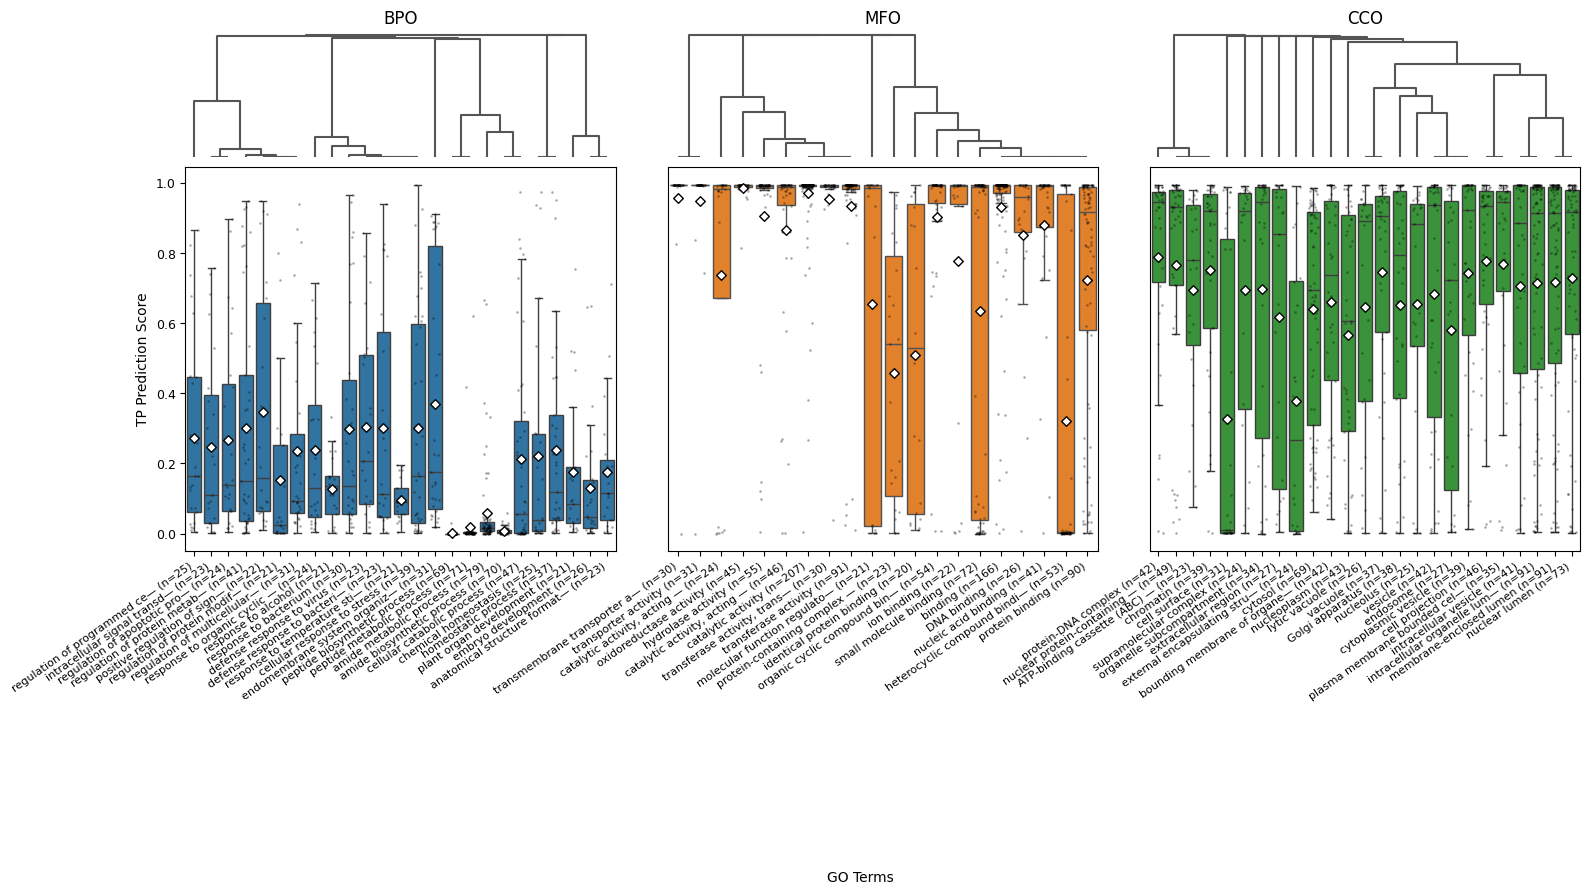

Saved: /home/atoffano/PFP_layer/notebooks/plots/tp_cluster_subplots_d1_raw_score.svg


In [9]:
run_tp_cluster_subplots_for_model(
    model_sub_pairs=TP_MODEL_SUBS,
    dataset='D1',
    split='test',
    subontologies=('BPO', 'MFO', 'CCO'),
    results_root=RESULTS_ROOT,
    data_root='/home/atoffano/PFP_layer/data',
    min_count=20,
    top_k=25,
    ic_weighted=False,
    ascending=True,
    linkage_method='average',
)


In [12]:
# ── CUR vs EXP median improvement per GO term ─────────────────────────────────

def _cur_exp_delta_for_sub(
    cur_model_dir, exp_model_dir, subontology,
    dataset='D1', split='test',
    results_root=RESULTS_ROOT,
    data_root='/home/atoffano/PFP_layer/data',
    min_gt_count=20,
):
    """
    For every GO term with ≥ min_gt_count ground-truth annotations, compute
    (CUR_median_score − EXP_median_score) across the proteins annotated
    to that term.  Returns a DataFrame with columns:
        term_ID, term_name, gt_count, cur_median, exp_median, delta
    sorted by delta descending.
    """
    gt_path   = os.path.join(data_root, dataset, f'{dataset}_{subontology}_{split}_annotations.tsv')
    cur_path  = os.path.join(results_root, dataset, cur_model_dir, 'predictions',
                             f'predictions_{split}_{subontology}.tsv')
    exp_path  = os.path.join(results_root, dataset, exp_model_dir, 'predictions',
                             f'predictions_{split}_{subontology}.tsv')

    df_gt     = _load_ground_truth(gt_path)
    df_cur    = _load_predictions(cur_path)
    df_exp    = _load_predictions(exp_path)

    if df_gt.empty or df_cur.empty or df_exp.empty:
        print(f"  [{subontology}] Missing data – skipping.")
        return pd.DataFrame()

    # Keep only terms with enough GT annotations
    gt_counts   = df_gt['term_ID'].value_counts()
    valid_terms = gt_counts[gt_counts >= min_gt_count].index

    # Vectorised: inner-join predictions with GT (target, term) pairs, then groupby
    gt_keys = df_gt[['target_ID', 'term_ID']].drop_duplicates()
    cur_tp  = df_cur.merge(gt_keys, on=['target_ID', 'term_ID'])
    exp_tp  = df_exp.merge(gt_keys, on=['target_ID', 'term_ID'])

    valid_set = set(valid_terms)
    cur_tp = cur_tp[cur_tp['term_ID'].isin(valid_set)]
    exp_tp = exp_tp[exp_tp['term_ID'].isin(valid_set)]

    if cur_tp.empty or exp_tp.empty:
        return pd.DataFrame()

    cur_med = cur_tp.groupby('term_ID')['score'].median().rename('cur_median')
    exp_med = exp_tp.groupby('term_ID')['score'].median().rename('exp_median')

    df_result = cur_med.to_frame().join(exp_med, how='inner').reset_index()
    df_result['term_name'] = df_result['term_ID'].map(_safe_go_name)
    df_result['gt_count']  = df_result['term_ID'].map(gt_counts).astype(int)
    df_result['delta']     = df_result['cur_median'] - df_result['exp_median']

    if df_result.empty:
        return pd.DataFrame()

    return df_result.sort_values('delta', ascending=False).reset_index(drop=True)


def _plot_improvement_bars(df_delta, title, ax, top_k=25, best=True, color_pos='tab:green', color_neg='tab:red'):
    """
    Horizontal barplot of CUR − EXP median score.
    best=True  → top_k largest deltas (improvements)
    best=False → top_k smallest deltas (regressions)
    """
    if df_delta.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        return

    if best:
        subset = df_delta.head(top_k).copy()
        subset = subset.sort_values('delta', ascending=True)     # ascending so best is at top
    else:
        subset = df_delta.tail(top_k).copy()
        subset = subset.sort_values('delta', ascending=False)    # descending so worst is at top

    labels = [f"{row.term_name}\n(n={row.gt_count})" for _, row in subset.iterrows()]
    colors = [color_pos if d >= 0 else color_neg for d in subset['delta']]

    ax.barh(range(len(subset)), subset['delta'].values, color=colors, edgecolor='black', linewidth=0.4)
    ax.set_yticks(range(len(subset)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('CUR − EXP  (median prediction score)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', labelsize=9)


def plot_cur_vs_exp_median_improvement(
    selected_model_dirs,
    dataset='D1',
    split='test',
    subontologies=('BPO', 'MFO', 'CCO'),
    results_root=RESULTS_ROOT,
    data_root='/home/atoffano/PFP_layer/data',
    min_gt_count=20,
    top_k=25,
):
    """
    For each subontology, find the first CUR model and first EXP model
    listed in *selected_model_dirs[dataset]*, compute per-term median score
    for proteins annotated to each term, and produce two horizontal-barplots:
      · Top-25 terms where CUR improved most over EXP
      · Worst-25 terms where CUR degraded most vs EXP
    Only GO terms with ≥ min_gt_count ground-truth annotations are included.
    """
    model_dirs = selected_model_dirs.get(dataset, [])
    cur_by_sub, exp_by_sub = {}, {}

    # Map subontology → first CUR / EXP model found in the list
    for d in model_dirs:
        for sub in subontologies:
            if sub not in cur_by_sub and 'CONTACT_ATTR_STRINGDB_CUR' in d:
                # Confirm a prediction file for this sub exists
                p = os.path.join(results_root, dataset, d, 'predictions',
                                 f'predictions_{split}_{sub}.tsv')
                if os.path.exists(p):
                    cur_by_sub[sub] = d
            if sub not in exp_by_sub and 'CONTACT_ATTR_STRINGDB' in d and 'CUR' not in d:
                p = os.path.join(results_root, dataset, d, 'predictions',
                                 f'predictions_{split}_{sub}.tsv')
                if os.path.exists(p):
                    exp_by_sub[sub] = d

    for sub in subontologies:
        cur_model = cur_by_sub.get(sub)
        exp_model = exp_by_sub.get(sub)
        if cur_model is None or exp_model is None:
            print(f"[{sub}] Missing CUR ({cur_model}) or EXP ({exp_model}) – skipping.")
            continue

        print(f"[{sub}]  CUR: {cur_model}")
        print(f"[{sub}]  EXP: {exp_model}")

        df_delta = _cur_exp_delta_for_sub(
            cur_model_dir=cur_model,
            exp_model_dir=exp_model,
            subontology=sub,
            dataset=dataset,
            split=split,
            results_root=results_root,
            data_root=data_root,
            min_gt_count=min_gt_count,
        )

        if df_delta.empty:
            continue

        # ── Two-panel figure: best / worst ─────────────────────────────────
        n_best  = min(top_k, len(df_delta))
        n_worst = min(top_k, len(df_delta))
        h_per_bar = 0.45
        fig_h = max(7, max(n_best, n_worst) * h_per_bar + 2)

        fig, (ax_best, ax_worst) = plt.subplots(
            1, 2, figsize=(20, fig_h), sharey=False,
        )

        _plot_improvement_bars(
            df_delta, title=f'{sub} – Top {n_best} improvements (CUR > EXP)',
            ax=ax_best, top_k=top_k, best=True,
        )
        _plot_improvement_bars(
            df_delta, title=f'{sub} – Worst {n_worst} regressions (CUR < EXP)',
            ax=ax_worst, top_k=top_k, best=False,
        )

        fig.suptitle(
            f'Median prediction score improvement: CUR vs EXP\n'
            f'{dataset} · {sub} · {split} split  (min GT count = {min_gt_count})',
            fontsize=13, y=1.01,
        )
        plt.tight_layout()
        save_and_show(fig, f'cur_vs_exp_improvement_{dataset.lower()}_{sub.lower()}.svg')


[BPO]  CUR: 20260214_110347_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR
[BPO]  EXP: 20260214_115223_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB


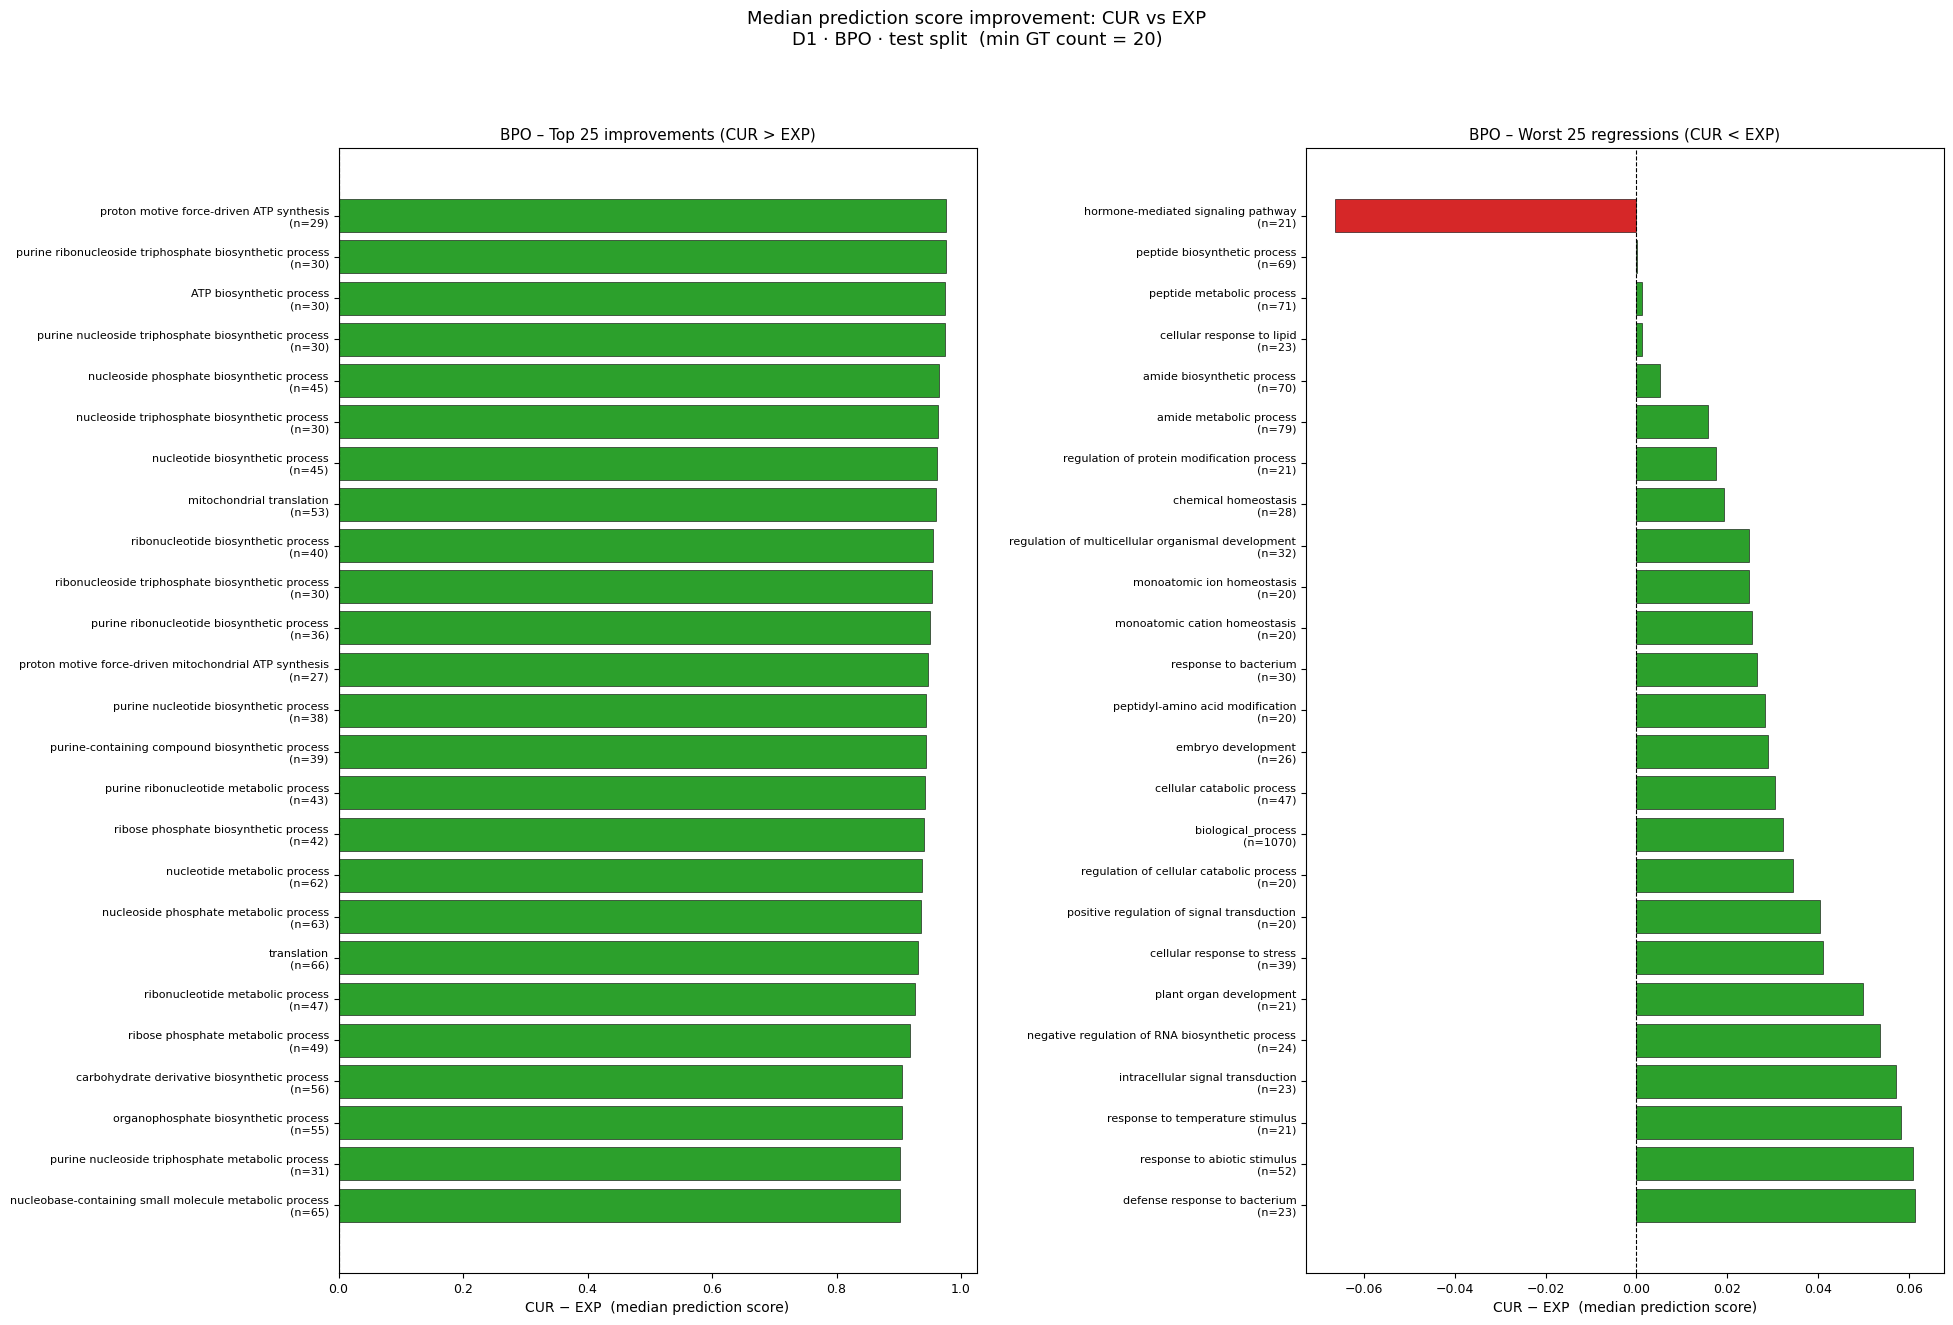

Saved: /home/atoffano/PFP_layer/notebooks/plots/cur_vs_exp_improvement_d1_bpo.svg
[MFO]  CUR: 20260214_100017_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR
[MFO]  EXP: 20260209_082957_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB


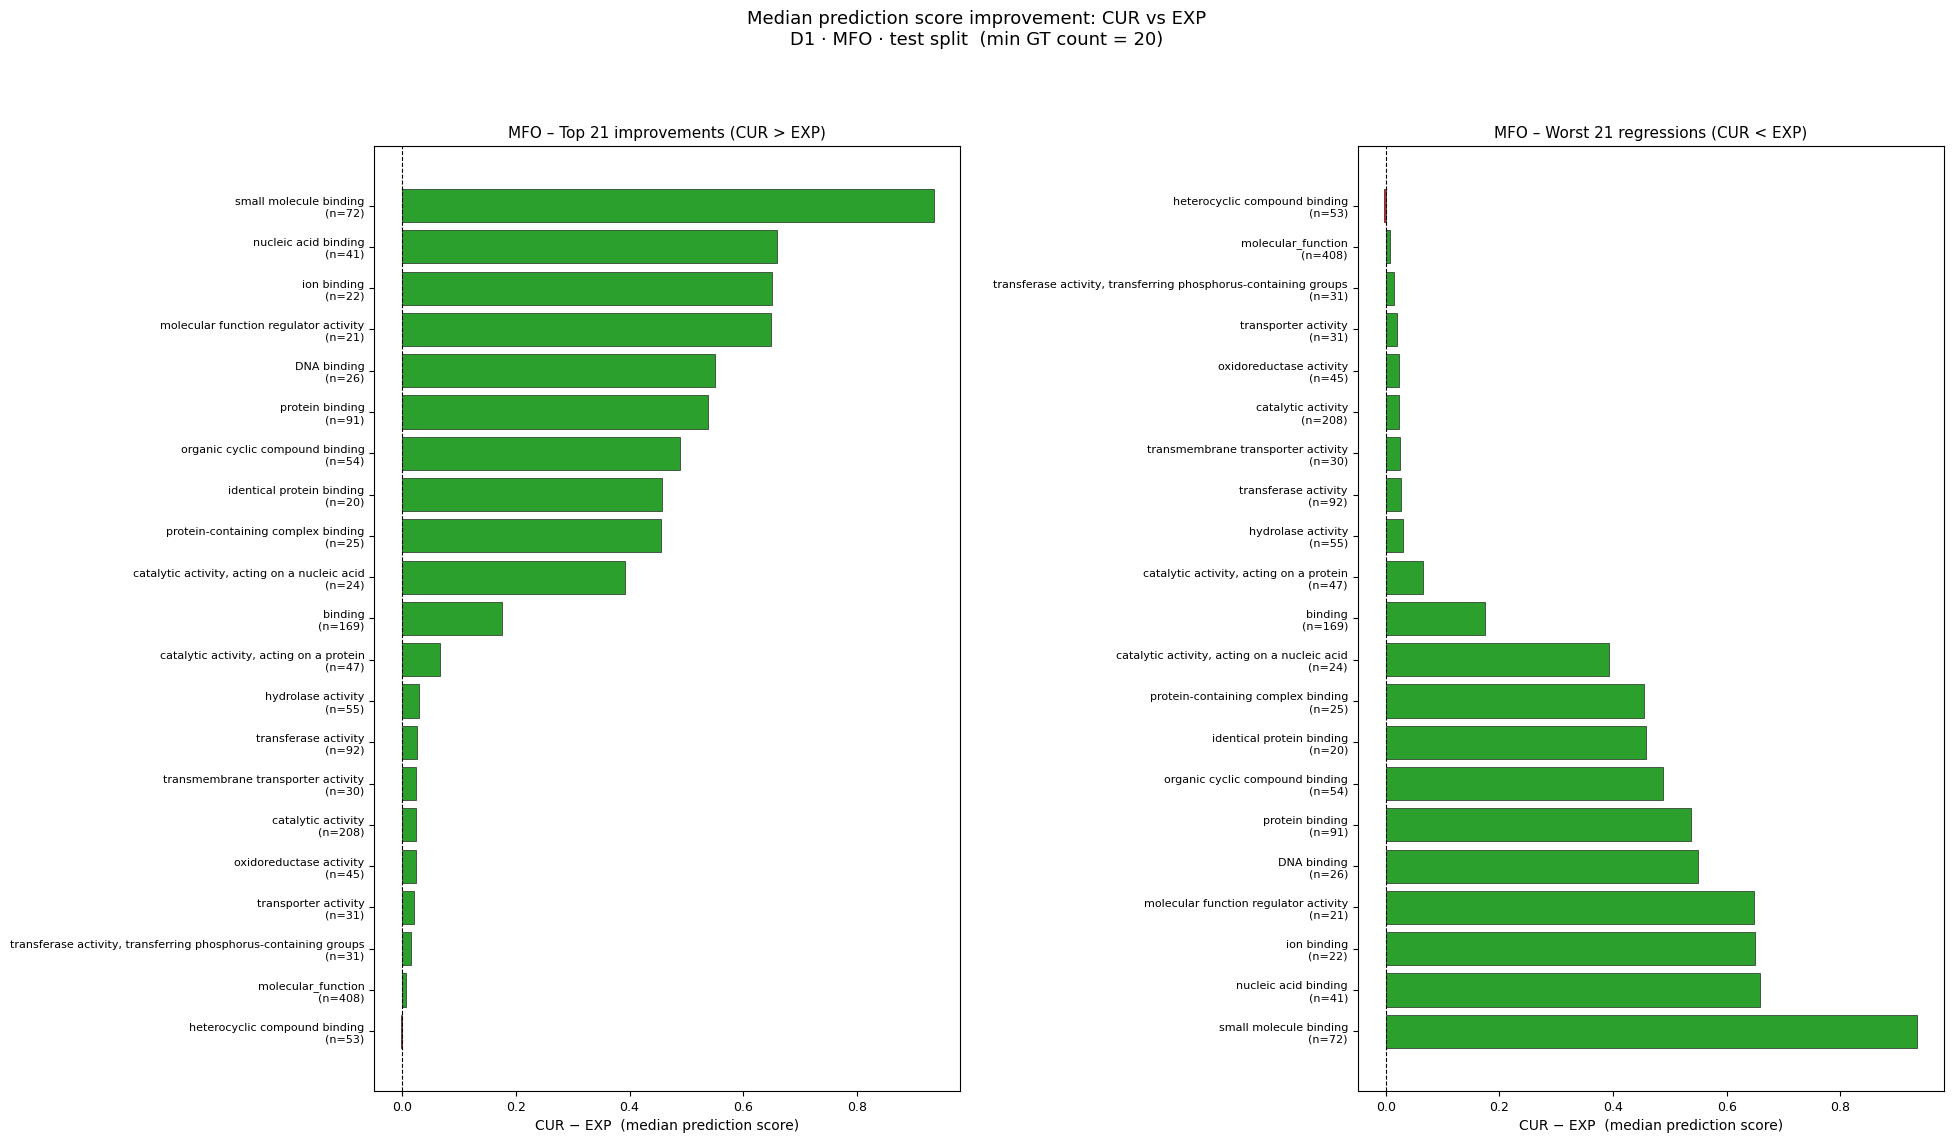

Saved: /home/atoffano/PFP_layer/notebooks/plots/cur_vs_exp_improvement_d1_mfo.svg
[CCO]  CUR: 20260214_105025_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR
[CCO]  EXP: 20260214_110603_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB


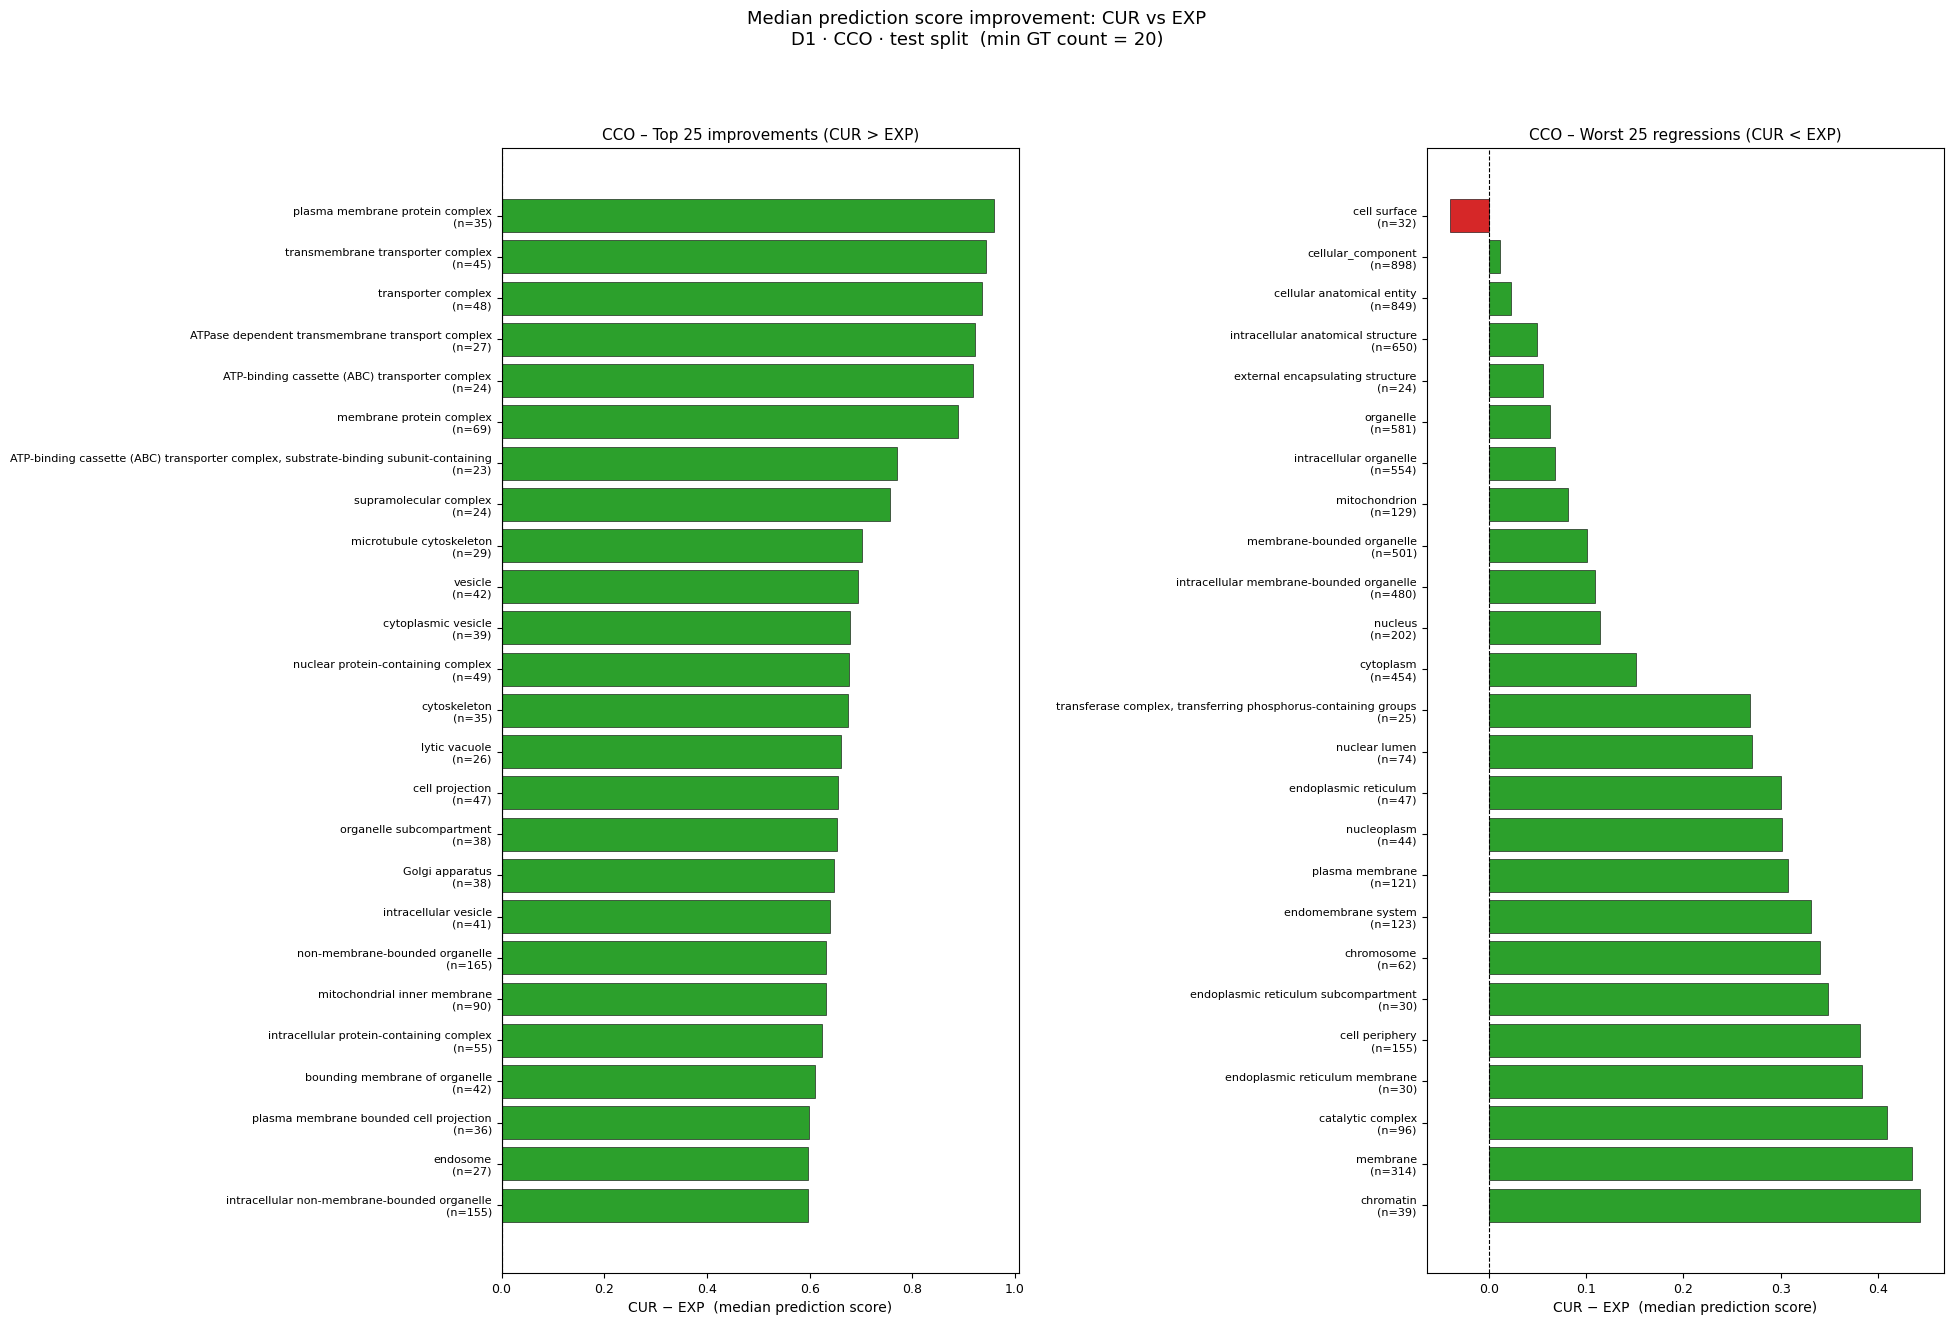

Saved: /home/atoffano/PFP_layer/notebooks/plots/cur_vs_exp_improvement_d1_cco.svg


In [13]:

SELECTED_MODEL_DIRS = {
    "D1": [
        "20260214_100017_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR",  # MFO
        "20260214_105025_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR",  # CCO
        "20260214_110347_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR",  # BPO
        "20260214_110603_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB",      # CCO
        "20260214_115223_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB",      # BPO
        "20260209_082957_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB",      # MFO
    ]
}

plot_cur_vs_exp_median_improvement(
    selected_model_dirs=SELECTED_MODEL_DIRS,
    dataset='D1',
    split='test',
    subontologies=('BPO', 'MFO', 'CCO'),
    results_root=RESULTS_ROOT,
    data_root='/home/atoffano/PFP_layer/data',
    min_gt_count=20,
    top_k=25,
)
